# Burn severity assessment of the Veluwe wildfire (Netherlands, 2026)

## Settings

### Packages

In [1]:
pkgs <- c("rstac", "sf", "lubridate", "dplyr", "terra", "tidyterra", "ggplot2")
invisible(lapply(pkgs, library, character.only = TRUE))

Linking to GEOS 3.13.0, GDAL 3.10.2, PROJ 9.5.1; sf_use_s2() is TRUE

Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

terra 1.8.42

Attaching package: ‘tidyterra’

The following object is masked from ‘package:stats’:

    filter



### Plotting options

In [2]:
options(repr.plot.width  =  12,
        repr.plot.height =   8,
        repr.plot.res    = 150)

theme_set(
  theme_bw() +
  theme(plot.title = element_text(size = 12, face = "bold", hjust = 0),
        plot.title.position = "plot",
        strip.text = element_text(size = 10, face = "bold"),
        axis.text = element_text(size = 10),
        axis.title = element_text(size = 10),
        legend.title = element_text(size = 11, face = "bold"),
        legend.text = element_text(size = 11),
        legend.key.width = unit(0.5, "cm"),
        legend.key.height = unit(0.5, "cm"),
        legend.position = "right")
)

pal_sev <- c("#0000ff", "#2eb82c", "#f1dd00", "#fda71d", "#d52903", "#6e01a3")

severity_classes <- data.frame(name = c("Regrowth", "Unburned", "Low",
                                        "Moderate", "High", "Very high"),
                               description = c("Vegetation regrowth", "Little to no damage",
                                               "Minor vegetation loss or early signs of damage",
                                               "Partial vegetation loss",
                                               "Significant vegetation loss",
                                               "Extensive vegetation loss and exposed soil"),
                               lower = c(-Inf, -0.1, 0.1, 0.27, 0.44, 0.66),
                               upper = c(-0.1, 0.1, 0.27, 0.44, 0.66, Inf),
                               color = pal_sev)

### Custom functions

In [3]:
## Convert dates to RFC3339 format
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, limit = 100,
                          start_date, end_date, target_date = NULL,
                          bbox = NULL, roi_path = NULL, thresh_cloud = NULL,
                          asset_names = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start_date, end_date), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange,
                  limit       = limit)
    
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }

    ### (Sub)select and fetch items
    items <- post_request(search)
    if(!is.null(thresh_cloud)) {
        items <- post_request(search)
        suppressWarnings(items <- items_filter(items, properties$`eo:cloud_cover` < thresh_cloud))
    }
    items <- items_fetch(items, progress = FALSE)
    if(!is.null(asset_names)) {
        items <- assets_select(items, asset_names = asset_names)
    }
    if(!is.null(target_date)) {
        target_date <- date2rfc3339(target_date)
        items <- items_select(items, selection = which(items_datetime(items) == as.Date(target_date)))
    }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

### Parameters

In [4]:
## STAC endpoint URL
cons_endpoint <- "https://planetarycomputer.microsoft.com/api/stac/v1"

## Dataset collection ID
param_collection <- "sentinel-2-l2a"

## Path to the file defining the region-of-interest
param_roi_path <- paste0(getwd(), "/data/rois/wf_veluwe_2026.gpkg")

## Target coordinate reference system code
param_crs_t <- "EPSG:32631"

## Start and end dates of the wildfire event
param_date_start <- "2026-04-29"
param_date_end <- "2026-04-30"

## Pre- and post-fire dates
param_date_pre <- "2026-04-22"
param_date_post <- "2026-05-07"

## Cloud cover threshold
param_thresh_cloud <- 30

## Asset codes
param_bands <- c("B02", "B03", "B04", "B8A", "B12")

## Path to the directory to save outputs
param_dir_out <- tempdir()
if (!dir.exists(param_dir_out)) dir.create(param_dir_out)

## Region of interest

### Import and reproject boundaries

In [5]:
## Netherlands
nl <- "data/rois/nl.gpkg" |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))

## Veluwe
veluwe <- "data/rois/veluwe.gpkg" |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))

## Burned area
roi <- param_roi_path |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))
roi_sv <- roi |>
  vect() |>
  project(param_crs_t)
roi_area <- roi$AREA_HA

### Visualize region of interest

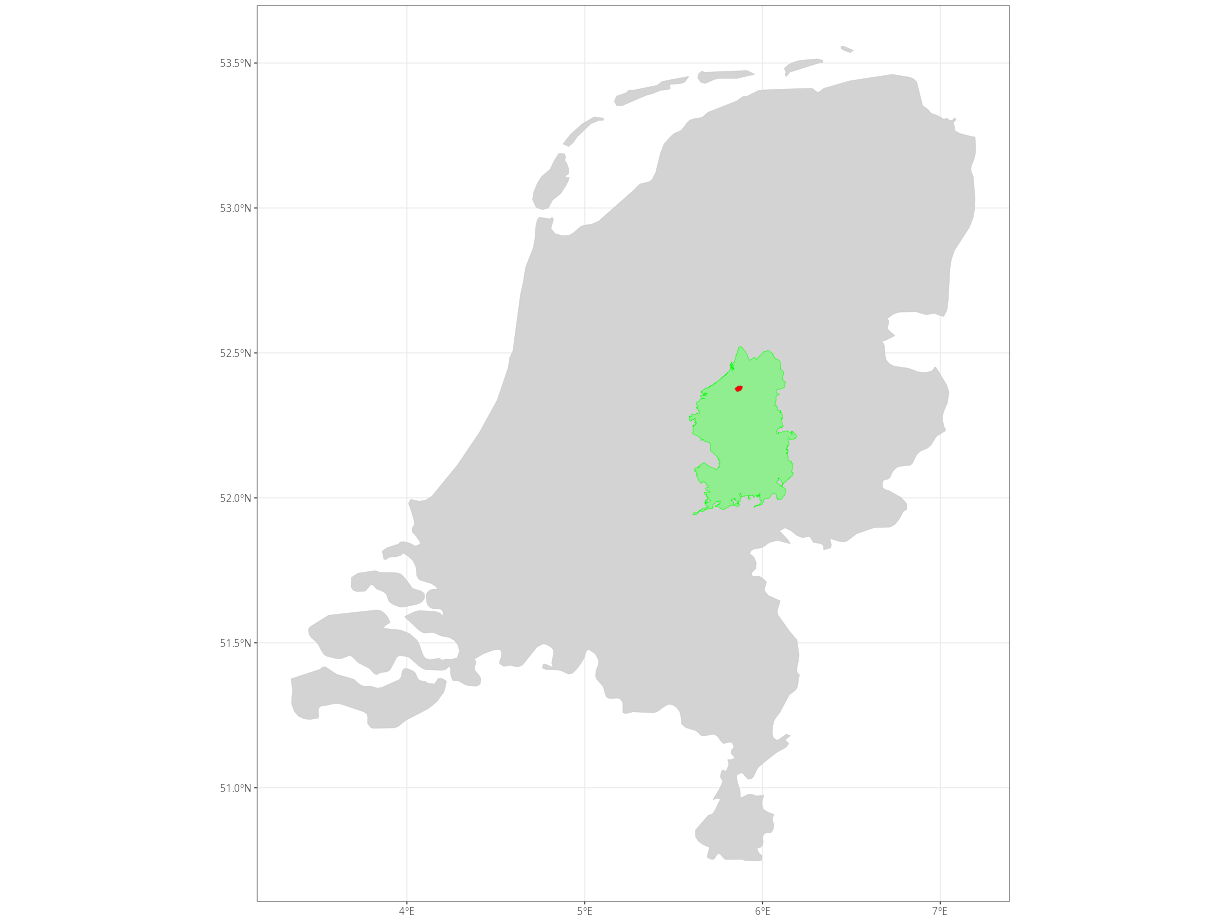

In [6]:
ggplot() +
  geom_sf(data = st_geometry(nl), fill = "lightgray", color = "grey") +
  geom_sf(data = st_geometry(veluwe), fill = "lightgreen", color = "green") +
  geom_sf(data = st_geometry(roi), fill = "red", color = "firebrick") +
  coord_sf(datum = st_crs(4326))

## Data downloading

### Query and fetch items

In [7]:
items <- stac(cons_endpoint) |>
  stac_search(collections = param_collection,
              datetime    = paste(lapply(c(param_date_pre, param_date_post),
                                         FUN = date2rfc3339), collapse = "/"),
              limit       = 100,
              intersects  = roi) |>
  post_request() |>
  items_sign_planetary_computer() |>
  items_filter(properties$`eo:cloud_cover` < 10) |>
  assets_select(asset_names = param_bands)
print(items)

###Items
- features (5 item(s)):
  - S2A_MSIL2A_20260501T104651_R051_T31UFU_20260501T173800
  - S2B_MSIL2A_20260501T103619_R008_T31UFU_20260501T143617
  - S2C_MSIL2A_20260429T105031_R051_T31UFU_20260429T144516
  - S2A_MSIL2A_20260428T104041_R008_T31UFU_20260428T173009
  - S2C_MSIL2A_20260426T104021_R008_T31UFU_20260426T160712
- assets: B02, B03, B04, B12, B8A
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type


### Download assets

In [8]:
assets_json <- assets_download(items       = items,
                               asset_names = param_bands,
                               output_dir  = param_dir_out,
                               overwrite   = TRUE,
                               use_gdal    = FALSE,
                               progress    = FALSE)
items_as_tibble(assets_json)

# A tibble: 5 × 32
  constellation datetime       `eo:cloud_cover` instruments platform `proj:epsg`
  <chr>         <chr>                     <dbl> <chr>       <chr>          <int>
1 Sentinel 2    2026-05-01T10…           0.0237 msi         Sentine…       32631
2 Sentinel 2    2026-05-01T10…           0.0699 msi         Sentine…       32631
3 Sentinel 2    2026-04-29T10…           9.72   msi         Sentine…       32631
4 Sentinel 2    2026-04-28T10…           2.58   msi         Sentine…       32631
5 Sentinel 2    2026-04-26T10…           6.79   msi         Sentine…       32631
# ℹ 26 more variables: `s2:cloud_shadow_percentage` <dbl>,
#   `s2:datastrip_id` <chr>, `s2:datatake_id` <chr>, `s2:datatake_type` <chr>,
#   `s2:degraded_msi_data_percentage` <dbl>, `s2:generation_time` <chr>,
#   `s2:granule_id` <chr>, `s2:high_proba_clouds_percentage` <dbl>,
#   `s2:mean_solar_azimuth` <dbl>, `s2:mean_solar_zenith` <dbl>,
#   `s2:medium_proba_clouds_percentage` <dbl>, `s2:mgrs_tile` <chr>,
#

### List downloaded files

In [9]:
dl_files <- list.files(path = param_dir_out, pattern = "*.tif",
                       full.names = TRUE, recursive = TRUE)
print(length(dl_files))

[1] 25


### Build properties table

In [10]:
dl_files_sep <- strsplit(dl_files, split = "/")
dl_files_df <- cbind(dl_files, as.data.frame(do.call(rbind, lapply(dl_files_sep, rbind))))
names(dl_files_df) <- c("path", "root", "dir", "subdir", "collection", "zone",
                        "area", "tile", "year", "month", "day", "band", "type",
                        "granule", "content", "resolution", "filename")

In [11]:
dl_files_df |>
  as_tibble() |>
  print()

# A tibble: 25 × 17
   path  root  dir   subdir collection zone  area  tile  year  month day   band 
   <chr> <chr> <chr> <chr>  <chr>      <chr> <chr> <chr> <chr> <chr> <chr> <chr>
 1 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    26    S2C_…
 2 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    26    S2C_…
 3 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    26    S2C_…
 4 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    26    S2C_…
 5 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    26    S2C_…
 6 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    28    S2A_…
 7 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    28    S2A_…
 8 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    28    S2A_…
 9 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    28    S2A_…
10 /tmp… ""    tmp   RtmpO… sentinel2… 31    U     FU    2026  04    28    S2A_…
# ℹ 15 m

### Select and import during-fire images

In [12]:
during_list <- dl_files_df |>
  filter(month == "04",
         day %in% c("29", "30"),
         resolution == "R10m")

In [13]:
s2_during <- rast(during_list$path)
names(s2_during) <- c("Blue", "Green", "Red")
print(s2_during)

class       : SpatRaster 
dimensions  : 10980, 10980, 3  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 6e+05, 709800, 5790240, 5900040  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
sources     : T31UFU_20260429T105031_B02_10m.tif  
              T31UFU_20260429T105031_B03_10m.tif  
              T31UFU_20260429T105031_B04_10m.tif  
names       : Blue, Green, Red 


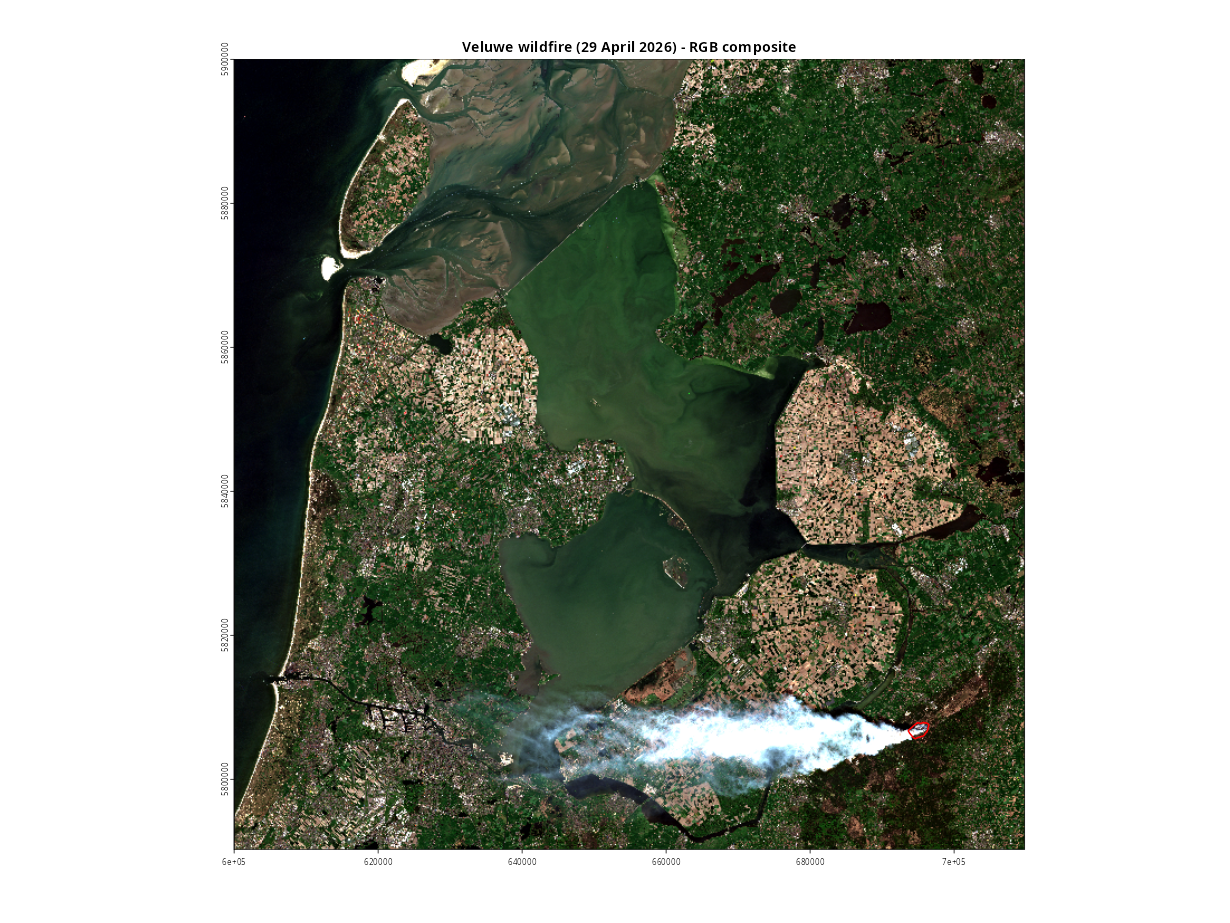

In [14]:
plotRGB(s2_during,
        r = 3, g = 2, b = 1,
        mar = NA,
        stretch = "lin",
        axes = TRUE,
        legend = FALSE,
        main = "Veluwe wildfire (29 April 2026) - RGB composite")
plot(roi_sv, add = TRUE, border = "red", lwd = 2)

### Select and import pre-fire images

In [15]:
pre_list <- dl_files_df |>
  filter(month == "04",
         day < "29",
         resolution == "R20m")
s2_pre <- rast(pre_list$path)
print(s2_pre)

class       : SpatRaster 
dimensions  : 5490, 5490, 4  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 6e+05, 709800, 5790240, 5900040  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
sources     : T31UFU_20260426T104021_B12_20m.tif  
              T31UFU_20260426T104021_B8A_20m.tif  
              T31UFU_20260428T104041_B12_20m.tif  
              T31UFU_20260428T104041_B8A_20m.tif  
names       : T31UFU_~B12_20m, T31UFU_~B8A_20m, T31UFU_~B12_20m, T31UFU_~B8A_20m 


### Select and import post-fire images

In [16]:
post_list <- dl_files_df |>
  filter(month == "05",
         day >= "01",
         resolution == "R20m")
s2_post <- rast(post_list$path)
print(s2_post)

class       : SpatRaster 
dimensions  : 5490, 5490, 4  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 6e+05, 709800, 5790240, 5900040  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
sources     : T31UFU_20260501T104651_B12_20m.tif  
              T31UFU_20260501T104651_B8A_20m.tif  
              T31UFU_20260501T103619_B12_20m.tif  
              T31UFU_20260501T103619_B8A_20m.tif  
names       : T31UFU_~B12_20m, T31UFU_~B8A_20m, T31UFU_~B12_20m, T31UFU_~B8A_20m 


## Pre-processing

### Crop pre-fire images

In [17]:
s2_pre_path <- paste0(param_dir_out, "/s2_pre.tif")
crop(x = s2_pre, y = buffer(roi_sv, 200), mask = FALSE,
     filename = s2_pre_path, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 2143073 114.5    3974081 212.3  2573494 137.5
Vcells 5023457  38.4   11496628  87.8 11488700  87.7

In [18]:
s2_pre_c <- rast(s2_pre_path)
names(s2_pre_c) <- paste0("pre", c("1_B12", "1_B8A", "2_B12", "2_B8A"))
print(s2_pre_c)

class       : SpatRaster 
dimensions  : 131, 161, 4  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_pre.tif 
names       : pre1_B12, pre1_B8A, pre2_B12, pre2_B8A 
min values  :     1479,     2404,     1458,     2402 
max values  :     5878,     5179,     5946,     5125 


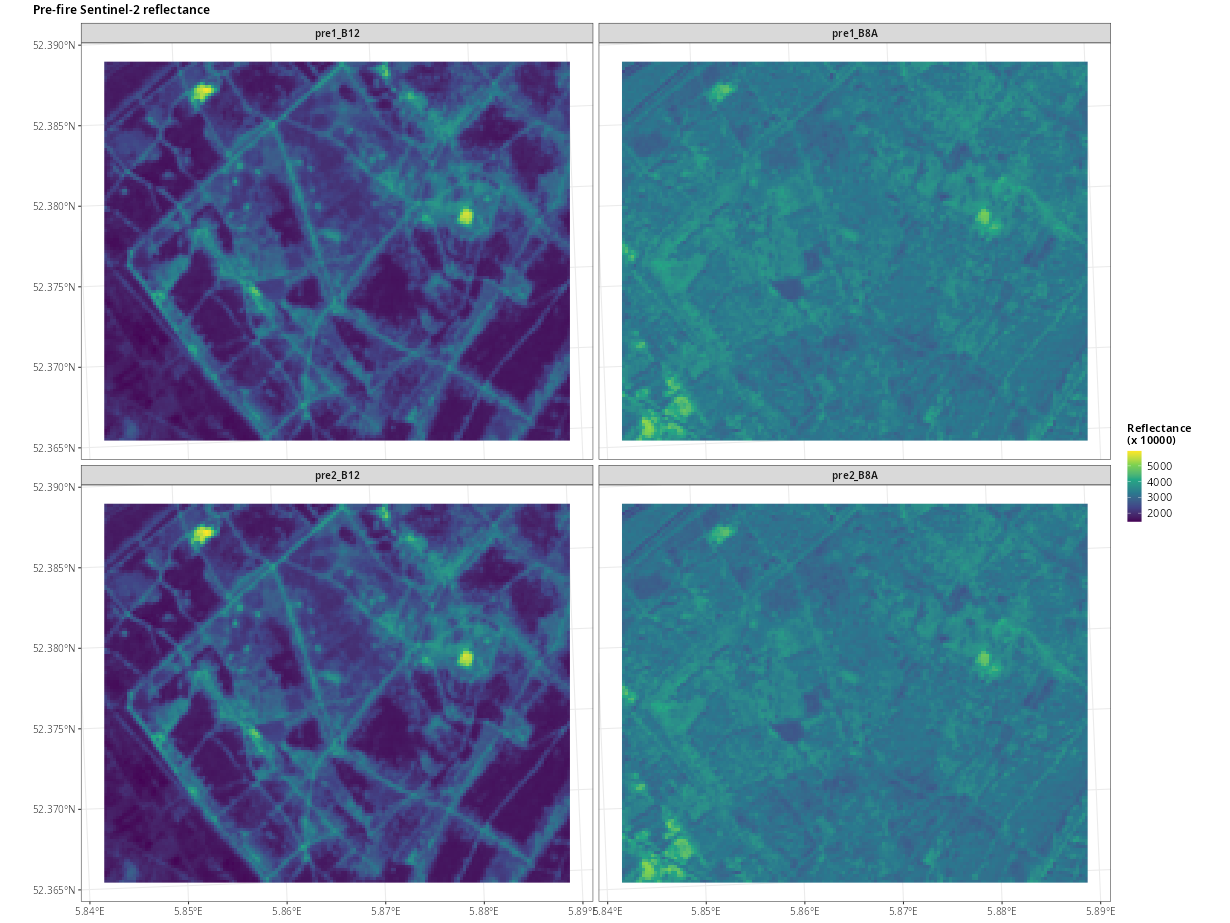

In [19]:
ggplot() +
  geom_spatraster(data = s2_pre_c) +
  scale_fill_viridis_c() +
  facet_wrap(~ lyr) +
  labs(title = "Pre-fire Sentinel-2 reflectance",
       fill = "Reflectance\n(x 10000)")

### Crop post-fire images

In [20]:
s2_post_path <- paste0(param_dir_out, "/s2_post.tif")
crop(x = s2_post, y = buffer(roi_sv, 200), mask = FALSE,
     filename = s2_post_path, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 2286716 122.2    3974081 212.3  3974081 212.3
Vcells 5449190  41.6   11496628  87.8 11488700  87.7

In [21]:
s2_post_c <- rast(s2_post_path)
names(s2_post_c) <- paste0("post", c("1_B12", "1_B8A", "2_B12", "2_B8A"))
print(s2_post_c)

class       : SpatRaster 
dimensions  : 131, 161, 4  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_post.tif 
names       : post1_B12, post1_B8A, post2_B12, post2_B8A 
min values  :      1396,      1324,      1472,      1372 
max values  :      5786,      5006,      6118,      5257 


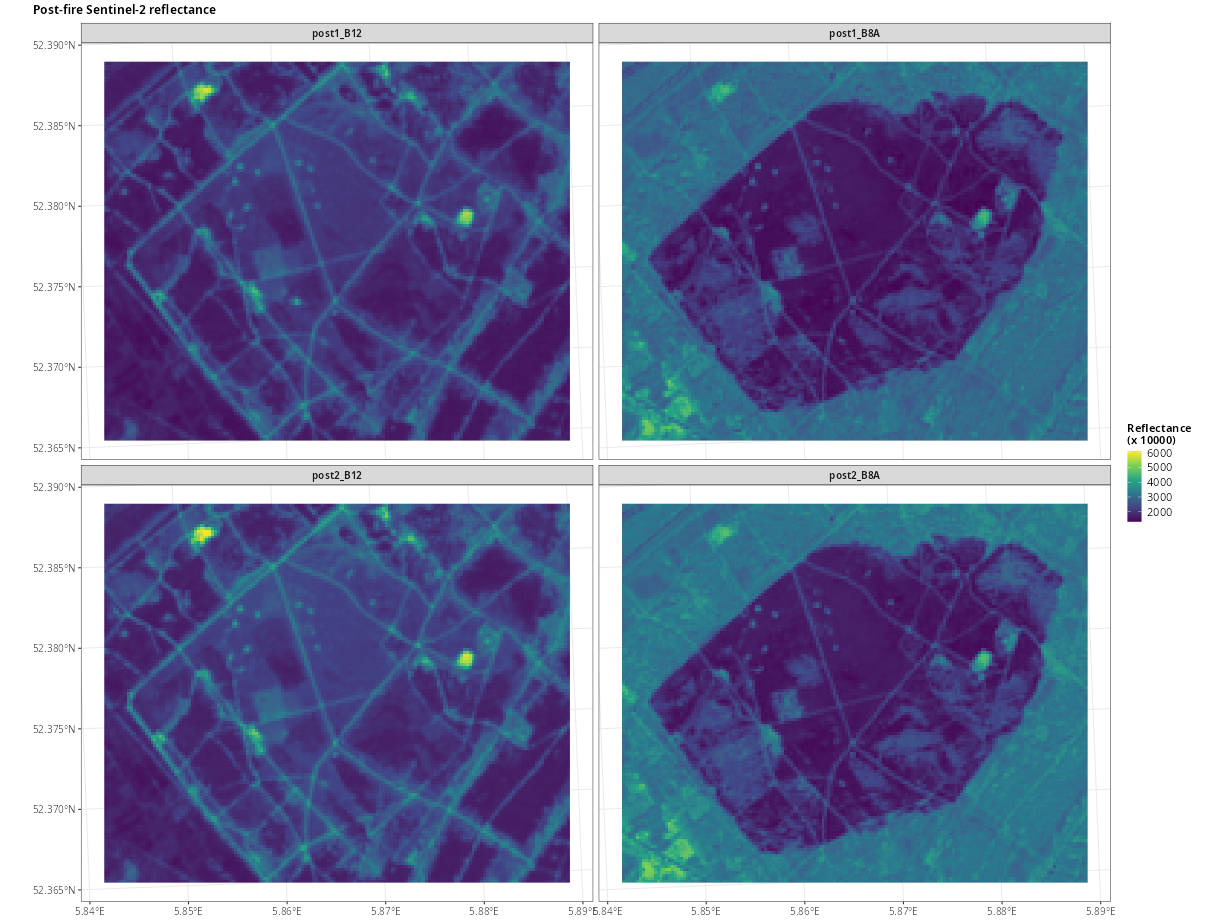

In [22]:
ggplot() +
  geom_spatraster(data = s2_post_c) +
  scale_fill_viridis_c() +
  facet_wrap(~ lyr) +
  labs(title = "Post-fire Sentinel-2 reflectance",
       fill = "Reflectance\n(x 10000)")

### Calculate multi-image averages

In [23]:
s2_pre_avg_path <- paste0(param_dir_out, "/s2_pre_avg.tif")
tapp(x = rast(s2_pre_path),
     index = c(1, 2, 1, 2),
     fun = \(x) mean(x, rm.na = TRUE), cores = 3,
     filename = s2_pre_avg_path, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 2326938 124.3    3974081 212.3  3974081 212.3
Vcells 5320889  40.6   11496628  87.8 11496628  87.8

In [24]:
s2_pre_avg <- rast(s2_pre_avg_path)
names(s2_pre_avg) <- paste0("pre_", c("B12", "B8A"))
print(s2_pre_avg)

class       : SpatRaster 
dimensions  : 131, 161, 2  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_pre_avg.tif 
names       : pre_B12, pre_B8A 
min values  :  1468.5,    2403 
max values  :  5912.0,    5152 


In [25]:
s2_post_avg_path <- paste0(param_dir_out, "/s2_post_avg.tif")
tapp(x = rast(s2_post_path),
     index = c(1, 2, 1, 2),
     fun = \(x) mean(x, rm.na = TRUE), cores = 3,
     filename = s2_post_avg_path, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 2327069 124.3    3974081 212.3  3974081 212.3
Vcells 5326482  40.7   11496628  87.8 11496628  87.8

In [26]:
s2_post_avg <- rast(s2_post_avg_path)
names(s2_post_avg) <- paste0("post_", c("B12", "B8A"))
print(s2_post_avg)

class       : SpatRaster 
dimensions  : 131, 161, 2  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_post_avg.tif 
names       : post_B12, post_B8A 
min values  :   1437.5,   1369.0 
max values  :   5932.0,   5097.5 


In [27]:
s2_avg_path <- paste0(param_dir_out, "/s2_avg.tif")
writeRaster(c(s2_pre_avg, s2_post_avg),
            filename = s2_avg_path, overwrite = TRUE)

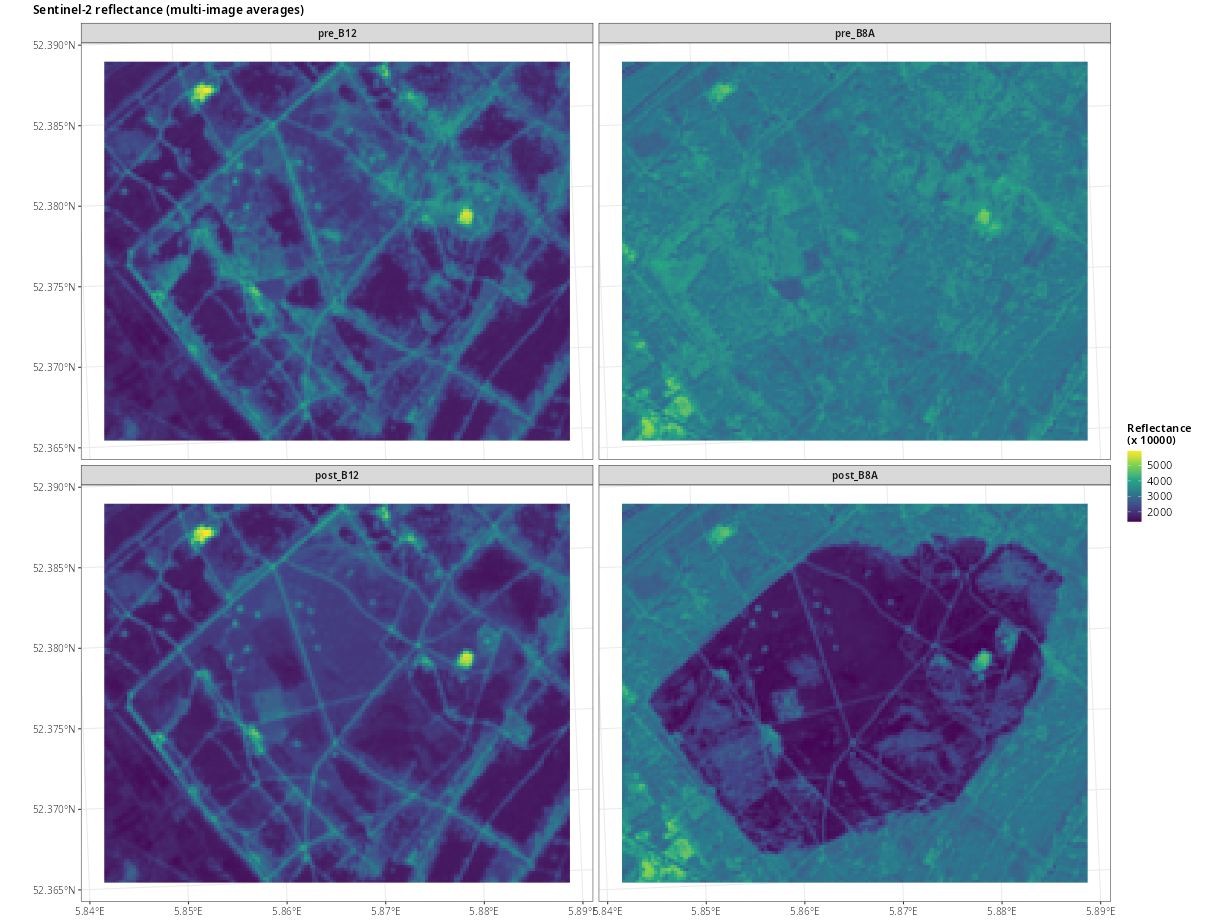

In [28]:
s2_avg <- rast(s2_avg_path)
ggplot() +
  geom_spatraster(data = s2_avg) +
  scale_fill_viridis_c() +
  facet_wrap(~ lyr) +
  labs(title = "Sentinel-2 reflectance (multi-image averages)",
       fill = "Reflectance\n(x 10000)")

## Burn severity assessment

### Compute NBR

The Normalized Burn Ratio (NBR) can be calculated, from the Sentinel-2 bands 8 (near-infrared, NIR) and 12 (shortwave-infrared, SWIR), using the following expression:

$`NBR = {(NIR - SWIR) \over{(NIR + SWIR)}}`$

In [29]:
s2_nbr_path <- paste0(param_dir_out, "/s2_nbr.tif")
tapp(x = s2_avg,
     index = c(1, 1, 2, 2),
     fun = \(x) (x[[2]] - x[[1]]) / (x[[2]] + x[[1]]), cores = 3,
     filename = s2_nbr_path, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 2347606 125.4    3974081 212.3  3974081 212.3
Vcells 5561879  42.5   11548678  88.2 11548678  88.2

In [30]:
s2_nbr <- rast(s2_nbr_path)
names(s2_nbr) <- paste0("nbr_", c("pre", "post"))
print(s2_nbr)

class       : SpatRaster 
dimensions  : 131, 161, 2  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_nbr.tif 
names       :    nbr_pre,   nbr_post 
min values  : -0.1347902, -0.3768004 
max values  :  0.4446704,  0.4802406 


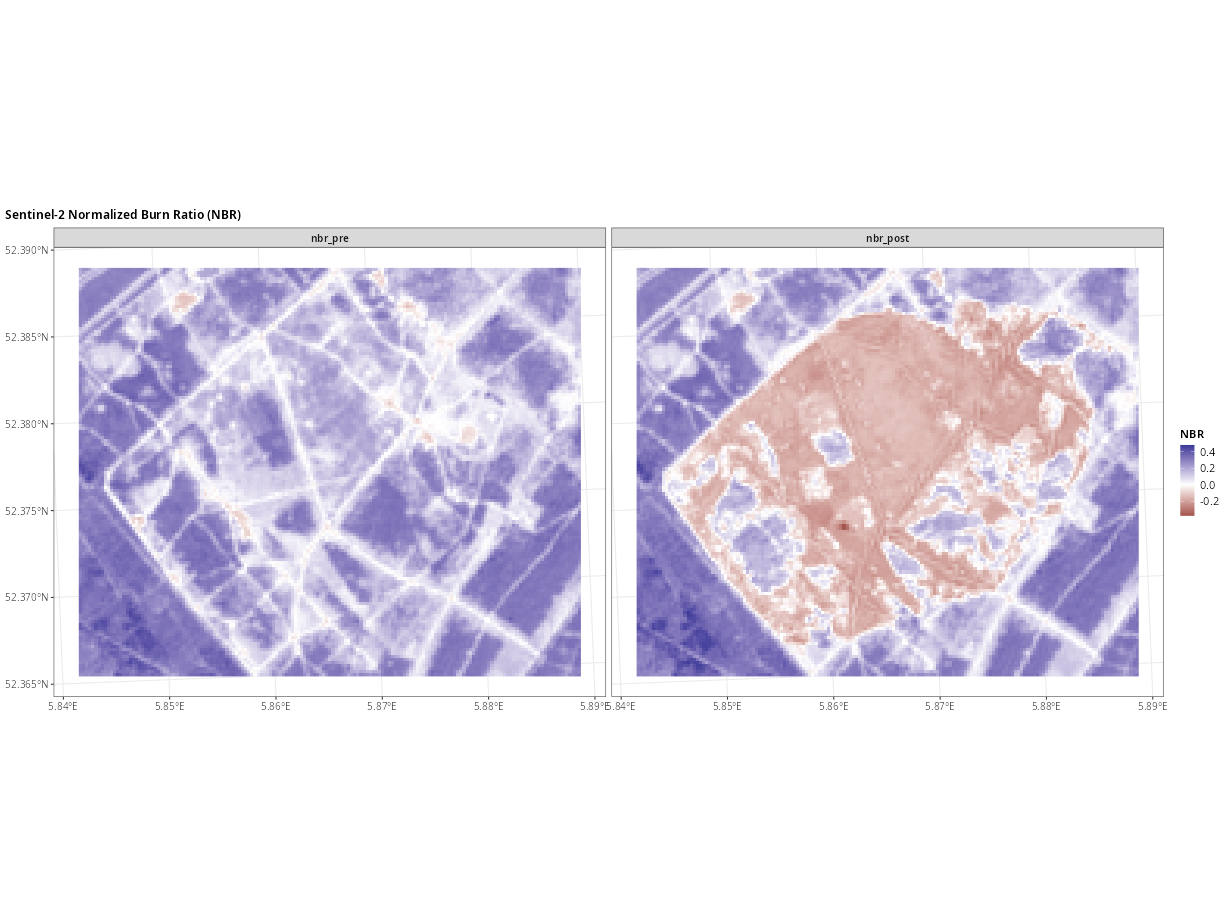

In [31]:
ggplot() +
  geom_spatraster(data = s2_nbr) +
  scale_fill_gradient2() +
  facet_wrap(~ lyr) +
  labs(title = "Sentinel-2 Normalized Burn Ratio (NBR)", fill = "NBR")

### Calculate dNBR

Burn severity can be mapped using Delta-NBR, calculated as follows:

$`dNBR = {NBR_{pre} - NBR_{post}}`$

In [32]:
s2_dnbr_path <- paste0(param_dir_out, "/s2_dnbr.tif")
app(x = rast(s2_nbr_path),
    fun = \(x) (x[[1]] - x[[2]]), cores = 3,
    filename = s2_dnbr_path, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 2363500 126.3    3974081 212.3  3974081 212.3
Vcells 5695751  43.5   11548678  88.2 11548678  88.2

In [33]:
s2_dnbr <- rast(s2_dnbr_path) |>
  crop(buffer(roi_sv, 200), mask = FALSE)
names(s2_dnbr) <- "dNBR"
print(s2_dnbr)

class       : SpatRaster 
dimensions  : 131, 161, 1  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 693460, 696680, 5805480, 5808100  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : s2_dnbr.tif 
name        :        dNBR 
min value   : -0.07949677 
max value   :  0.70653677 


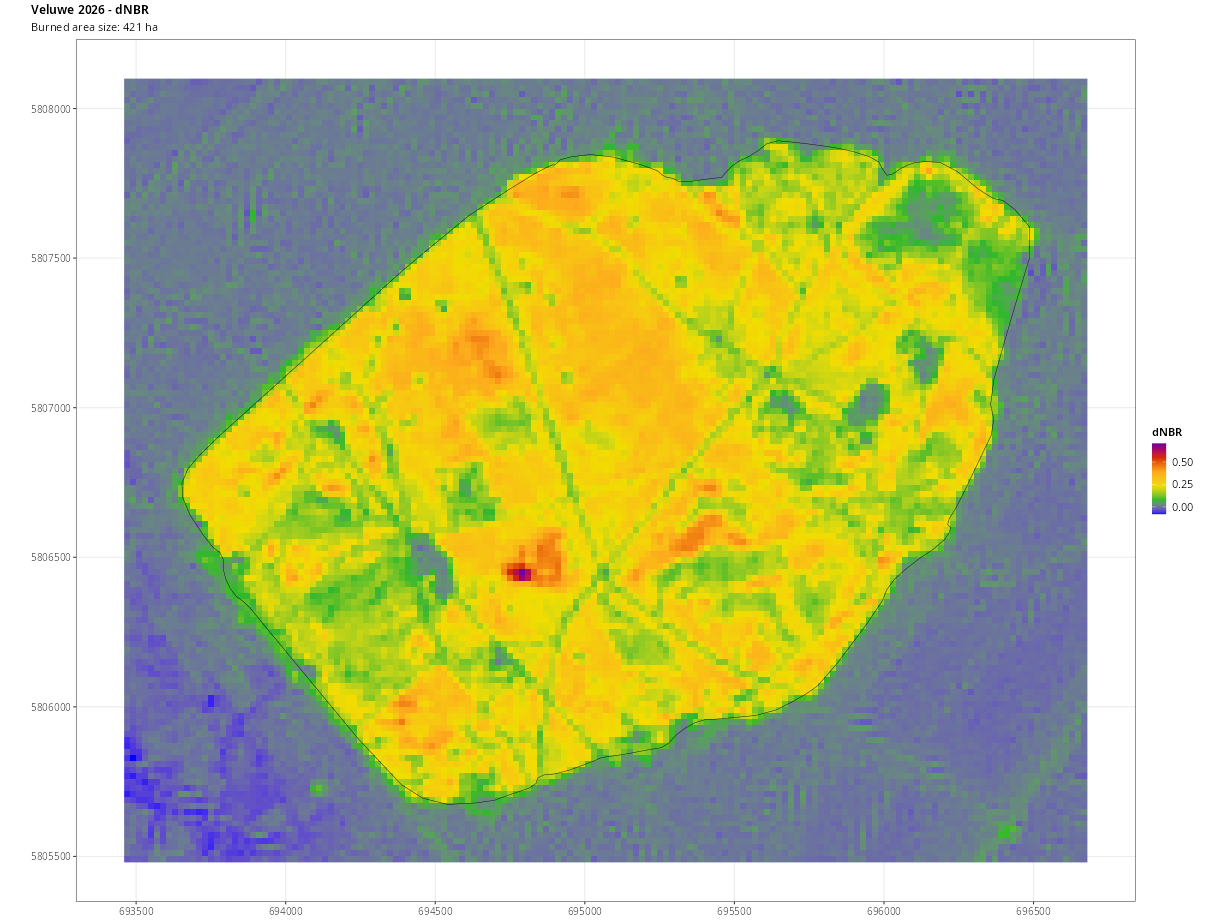

In [34]:
gg_dnbr <- ggplot() +
  geom_spatraster(data = s2_dnbr, aes(fill = dNBR)) +
  geom_spatvector(data = roi_sv, color = "black", fill = "transparent") +
  coord_sf(datum = st_crs(32631)) +
  scale_fill_gradientn(colors = pal_sev) +
  labs(title = "Veluwe 2026 - dNBR", fill = "dNBR",
       subtitle = paste("Burned area size:", roi_area, "ha"))

ggsave(plot = gg_dnbr,
       device = "png",
       filename = "out/figures/s2-dnbr_veluwe2026.png",
       width = 16,
       height = 11,
       units = "cm",
       dpi = "print")

print(gg_dnbr)

## Classify burn severity

Delta Normalized Burn Ratio (dNBR) classes derived from Sentinel-2 imagery quantify wildfire and burn severity by calculating the difference between pre- and post-fire Normalized Burn Ratio (NBR) values.

These categories are mapped according to standard thresholds initially defined by the USGS and Monitoring Trends in Burn Severity (MTBS) programs.

The standard dNBR severity classification ranges are generally divided as follows:

| Burn Severity Class | dNBR Value Range | Description                                                  |
| :------------------ | ---------------: | :----------------------------------------------------------- |
| Enhanced Regrowth   |         < -0.100 | High post-fire vegetation productivity or new growth.        |
| Unburned            | -0.100 to +0.100 | Minimal or no change to vegetation cover.                    |
| Low Severity        | +0.101 to +0.269 | Scorched understory, minimal canopy tree mortality.          |
| Moderate Severity   | +0.270 to +0.439 | Partial canopy scorch, mixed severity.                       |
| High Severity       | +0.440 to +0.659 | Widespread canopy consumption or heavy charring.             |
| Very High Severity  | > 0.659          | Complete consumption of overstory and understory vegetation. |

### Map burn severity classes

In [35]:
s2_sev <- s2_dnbr |>
  crop(roi_sv, mask = TRUE) |>
  mutate(sev = cut(dNBR, breaks = c(-Inf, severity_classes$upper),
                         labels = severity_classes$name))

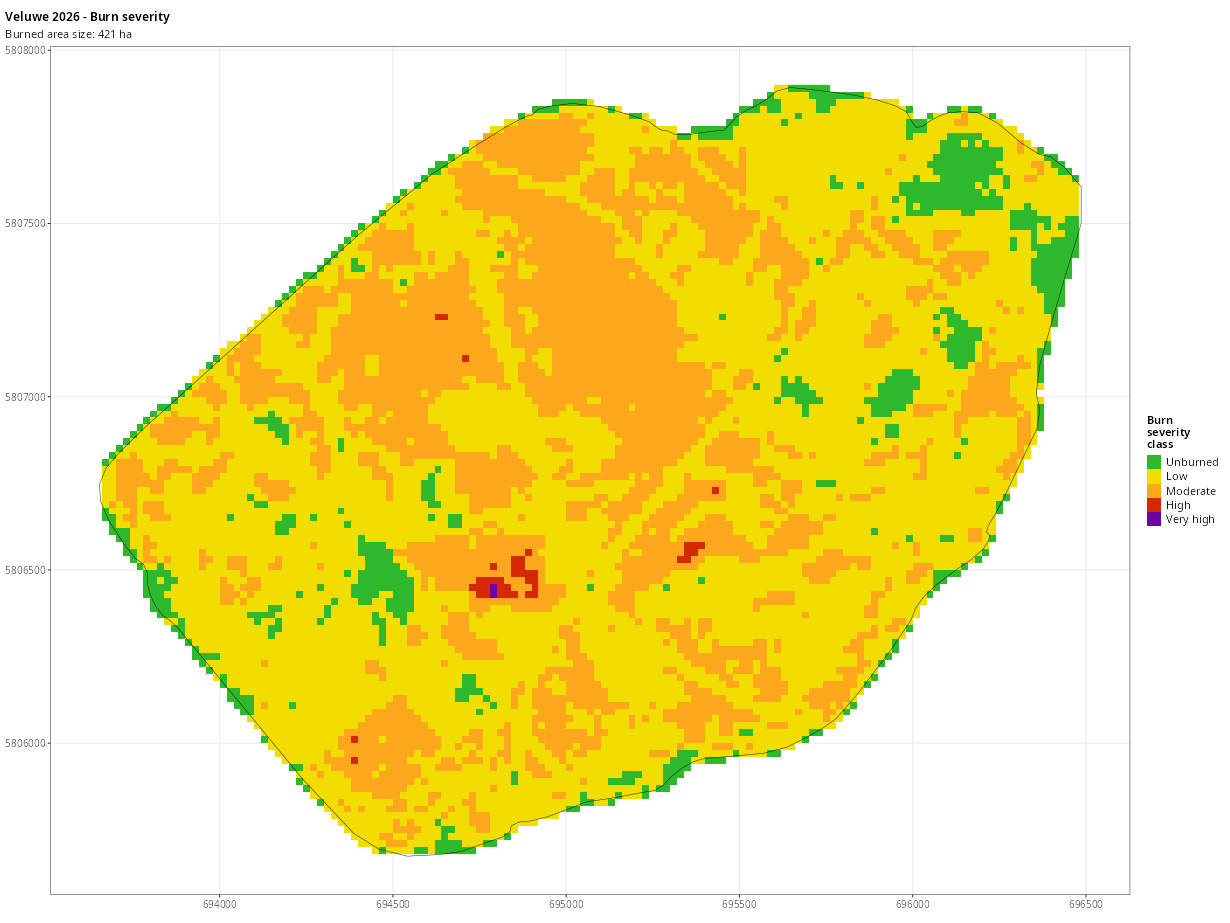

In [36]:
gg_dnbr_class <- ggplot() +
  geom_spatraster(data = s2_sev, aes(fill = sev)) +
  geom_spatvector(data = roi_sv, color = "black", fill = "transparent") +
  coord_sf(datum = st_crs(32631)) +
  scale_fill_manual(values = pal_sev[-1], na.translate = FALSE) +
  labs(title = "Veluwe 2026 - Burn severity", fill = "Burn\nseverity\nclass",
       subtitle = paste("Burned area size:", roi_area, "ha"))

ggsave(plot = gg_dnbr_class,
       device = "png",
       filename = "out/figures/s2-dnbr_veluwe2026_classified.png",
       width = 16,
       height = 10,
       units = "cm",
       dpi = "print")

print(gg_dnbr_class)

### Analyze distributions and compare with the Rhodes 2023 wildfire

In [37]:
dnbr_df <- as.data.frame(
  rbind(cbind(read.csv("out/tables/dnbr_rhodes.csv")$x, "Rhodes 2023"),
        cbind(read.csv("out/tables/dnbr_veluwe.csv")$x, "Veluwe 2026"))
)
names(dnbr_df) <- c("dNBR", "Wildfire")
dnbr_df$dNBR <- as.double(dnbr_df$dNBR)

Warning messages:
1: Removed 442 rows containing non-finite outside the scale range
(`stat_ydensity()`). 
2: Removed 442 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
Warning messages:
1: Removed 442 rows containing non-finite outside the scale range
(`stat_ydensity()`). 
2: Removed 442 rows containing non-finite outside the scale range
(`stat_boxplot()`). 


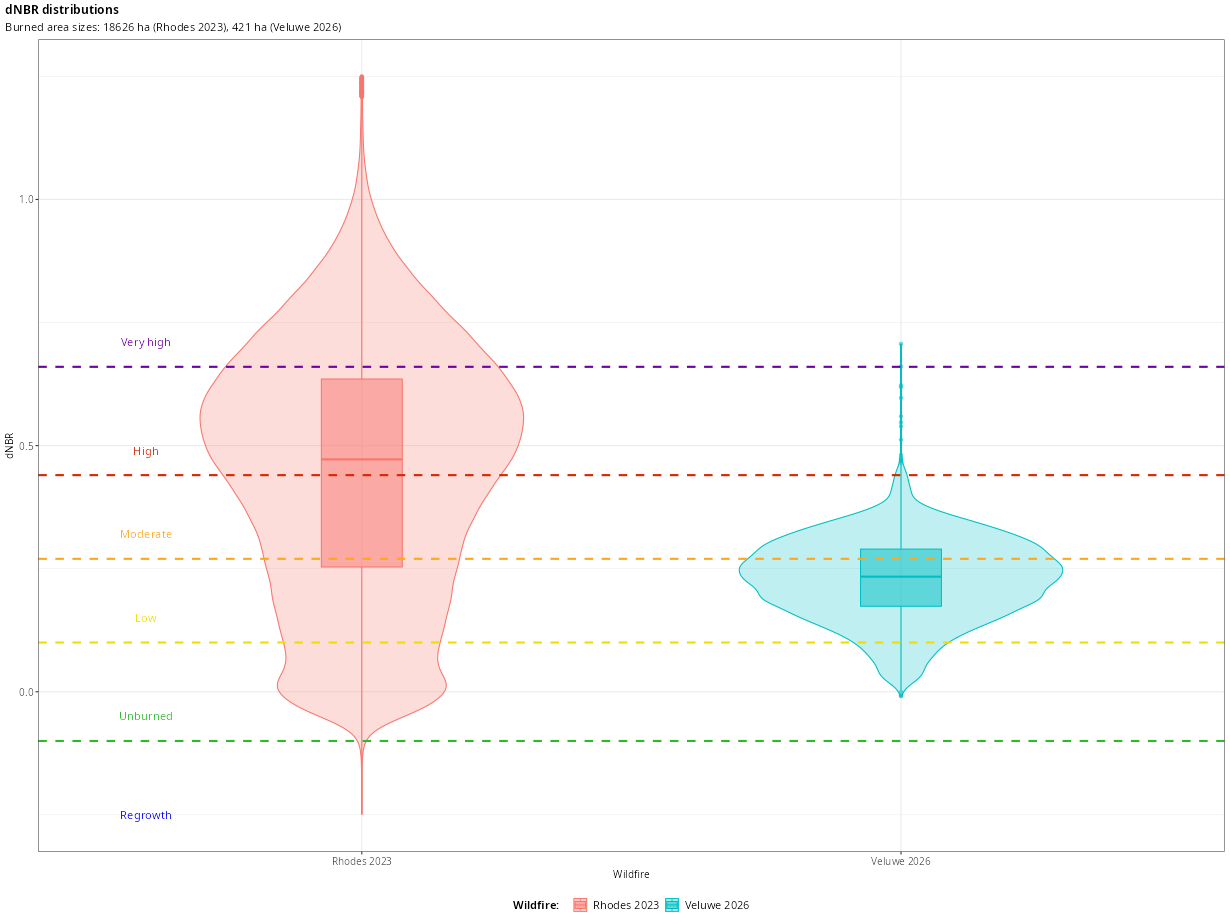

In [40]:
gg_dnbr_dist <- dnbr_df |>
  ggplot(aes(x = Wildfire, y = dNBR, group = Wildfire, fill = Wildfire, color = Wildfire)) +
  geom_violin(alpha = 0.25, width = 0.6, scale = "width") +
  geom_boxplot(alpha = 0.5, width = 0.15) +
  geom_hline(yintercept = severity_classes$lower[-1],
             color = severity_classes$color[-1],
             linetype = "dashed", linewidth = 1) +
  annotate(geom = "text", size = 4,
           x = 0.6, y = c(-0.25, severity_classes$lower[-1] + 0.05),
           label = severity_classes$name,
           color = severity_classes$color) +
  ylim(-0.25, 1.25) +
  theme(legend.position = "bottom") +
  labs(title = "dNBR distributions",
       subtitle = paste("Burned area sizes: 18626 ha (Rhodes 2023),",
                        roi_area, "ha (Veluwe 2026)"),
       x = "Wildfire", y = "dNBR",
       fill = "Wildfire:   ", color = "Wildfire:   ")

ggsave(plot = gg_dnbr_dist,
       device = "png",
       filename = "out/figures/s2-dnbr_comparison_distributions.png",
       width = 16,
       height = 24,
       units = "cm",
       dpi = "print")

print(gg_dnbr_dist)